# 66 - Your First CNN

**Section:** CNNs | **Prereqs:** all of `Convolution and transformations/` | **Next:** `CNNs/CNN_MNIST_ROLLED.ipynb`

MNIST again, this time with convolution. Compare with `FNNs/MNIST.ipynb`: higher
accuracy, far fewer parameters, and - as the next notebook shows - it survives
shifted inputs.

**The standard CNN skeleton**

    [Conv -> ReLU -> Pool] x N  ->  flatten  ->  [Linear -> ReLU] x M  ->  Linear(classes)

Channels grow (1 -> 64 -> 128 -> 256) while spatial size shrinks (28 -> 14 -> 7 -> ...).
Early layers see small patches and learn edges; later layers see large receptive
fields and learn parts and shapes.

**Global average pooling.** `AdaptiveAvgPool2d((1,1))` collapses each channel to
one number, so the vector entering the classifier is exactly `out_channels` long
regardless of input image size. It replaces the fragile hand-computed flatten
size, and it has no parameters where a big `Linear` would have thousands.

**The flatten step:** `x.view(x.size(0), -1)` keeps the batch dimension and
flattens everything else. Writing `x.view(-1, 256)` would work here too, but the
first form is safer - it can never silently merge samples together.

**Also here:** the custom Dataset from the previous section, with random
horizontal flips on train and none on validation. Note that a horizontal flip is
questionable for digits (a mirrored 2 is not a 2) - it is a demonstration of the
mechanism rather than a good augmentation for this data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

import torchvision
import torchvision.transforms as T

from torchsummary import summary

from sklearn.model_selection import train_test_split


In [2]:
# MNIST without a transform - the transform is applied by the custom Dataset
# below instead, per sample.
raw_data_train = torchvision.datasets.MNIST(root='/data', train=True, download=True)
raw_data_test = torchvision.datasets.MNIST(root='/data', train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 335kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 32.3MB/s]


In [3]:
# (60000,28,28) train and (10000,28,28) test.
raw_data_train.data.shape, raw_data_test.data.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

In [4]:
raw_data_train.targets.shape

torch.Size([60000])

In [5]:
# 90/10 train/validation split from the training set, so the official test set
# stays untouched until the end.
# .detach().clone() is the correct way to copy a tensor; torch.tensor(t) warns.
device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_data , val_data , train_label, val_label = train_test_split(raw_data_train.data, raw_data_train.targets, test_size=0.10)

train_data = train_data.detach().clone().to(dtype=torch.float, device=device)
val_data = val_data.detach().clone().to(dtype=torch.float, device=device)

train_label = train_label.detach().clone().to(dtype=torch.long, device=device)
val_label = val_label.detach().clone().to(dtype=torch.long, device=device)

device

'cuda'

In [6]:
# TensorDataset?? prints its source - the template for the class below.
TensorDataset??

In [7]:
# A custom Dataset (see Convolution and transformations/Creating_Custom_DataLoaders)
# so a transform pipeline can run per sample, per epoch.
# The size guard uses any(...): it fires as soon as ONE tensor has a different
# length. all(...) would only fire when every tensor mismatched, which is not
# the condition you want to catch.
class MNIST_Dataset(Dataset):
    r"""Dataset wrapping tensors.

    Each sample will be retrieved by indexing tensors along the first dimension.

    Args:
        *tensors (Tensor): tensors that have the same size of the first dimension.
    """

    def __init__(self, tensors , transformations=None) -> None:
        if any(tensors[0].size(0) != tensor.size(0) for tensor in tensors):
            raise AssertionError("Size mismatch between tensors")
        self.tensors = tensors
        self.transformations = transformations

    def __getitem__(self, index):
      if self.transformations:
        X = self.transformations(self.tensors[0][index])
        Y = self.tensors[1][index]
        return (X,Y)
      else:
        return tuple(tensor[index] for tensor in self.tensors)

    def __len__(self) -> int:
        return self.tensors[0].size(0)

In [8]:
issubclass(MNIST_Dataset, Dataset)

True

In [9]:
# Different pipelines for train and validation: random flips only on train.
# Never augment the evaluation set - it makes your score noisy and
# irreproducible. (A horizontal flip is a poor choice for digits regardless;
# rotation or small translation would be label-preserving.)
train_transformation = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor()
])

val_transformation = T.Compose([
    T.ToPILImage(),
    T.ToTensor()
])

train_transformation, val_transformation

(Compose(
     ToPILImage()
     RandomHorizontalFlip(p=0.5)
     ToTensor()
 ),
 Compose(
     ToPILImage()
     ToTensor()
 ))

In [10]:
# Loaders. Batch 256 - CNNs are compute-heavy per sample, so bigger batches use
# the GPU better.
train_dataset = MNIST_Dataset((train_data,train_label), train_transformation)
val_dataset = MNIST_Dataset((val_data,val_label), val_transformation)

bs = 256
train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=val_dataset.tensors[0].shape[0])

In [11]:
train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x7e7eb10da2d0>,
 <torch.utils.data.dataloader.DataLoader at 0x7e7eb23dd730>)

In [12]:
# The CNN. Read the shape at each stage - this is the part to internalise:
#   input             (N, 1, 28, 28)
#   conv1 s=2 + pool  -> 64 channels, 7x7
#   conv2 s=1 + pool  -> 128 channels, 3x3
#   conv3 s=2 + pool  -> 256 channels, 1x1
#   gap               -> (N, 256, 1, 1)
#   view              -> (N, 256)   flatten for the Linear layers
#   fc1 -> out        -> (N, 10)
#
# Channels go UP (1 -> 64 -> 128 -> 256) while spatial size goes DOWN. That is
# the standard CNN shape: trade 'where' for 'what', ending with many abstract
# features at almost no spatial resolution.
#
# AdaptiveAvgPool2d((1,1)) averages each channel to a single number, so the
# flattened size is exactly out_channels no matter the input image size. That is
# what makes the model input-size independent, and it removes the hand-computed
# flatten size that breaks so many CNNs.

class MNIST_Model(nn.Module):

  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1,64, kernel_size=3, padding=1,stride=2)   # 28 -> 14, then pool -> 7
    self.conv2 = nn.Conv2d(64,128,kernel_size=3, padding=1, stride=1)  # 7 -> 7, then pool -> 3
    self.conv3 = nn.Conv2d(128,256,kernel_size=3, padding=1, stride=2)

    self.gap = nn.AdaptiveAvgPool2d((1,1))

    self.fc1 = nn.Linear(256,64)
    self.out = nn.Linear(64,10)


    self.pool = nn.MaxPool2d(2,2)


  def forward(self, x):

    x = self.pool(F.relu((self.conv1(x))))

    x =  self.pool(F.relu((self.conv2(x))))

    x =  self.pool(F.relu((self.conv3(x))))

    x = self.gap(x)

    x = x.view(x.size(0), -1)

    x = F.relu(self.fc1(x))

    return self.out(x)

In [13]:
# Instantiate on the GPU.
model = MNIST_Model().to(device)
model

MNIST_Model(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [14]:
# torchsummary prints the output shape after every layer and the parameter
# count. Run this whenever you build a CNN - it catches shape errors before
# training does, and shows where the parameters actually are.
summary(model , (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 14, 14]             640
         MaxPool2d-2             [-1, 64, 7, 7]               0
            Conv2d-3            [-1, 128, 7, 7]          73,856
         MaxPool2d-4            [-1, 128, 3, 3]               0
            Conv2d-5            [-1, 256, 2, 2]         295,168
         MaxPool2d-6            [-1, 256, 1, 1]               0
 AdaptiveAvgPool2d-7            [-1, 256, 1, 1]               0
            Linear-8                   [-1, 64]          16,448
            Linear-9                   [-1, 10]             650
Total params: 386,762
Trainable params: 386,762
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.19
Params size (MB): 1.48
Estimated Total Size (MB): 1.67
-------------------------------------------

In [37]:
# Training. One CNN-specific detail: x.to(device) inside the loop is required
# because ToPILImage in the transform pipeline moves the tensor back to CPU.
# SGD with lr=0.25 and momentum=0.9 - a high rate that works here because the
# gradients are small and well-conditioned.
def train_model():

  model = MNIST_Model().to(device)

  lossfunc = nn.CrossEntropyLoss()
  epochs = 25
  optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.25,
    momentum=0.9,
    )


  losses = []
  train_acc = []
  val_acc = []

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:
      x = x.to(device) # ToPILimage takes it back to cpu
      y = y.to(device)
      yhat = model(x)

      loss = lossfunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      val_acc.append( 100 * torch.mean( (torch.argmax(model(X), dim=1) == Y).float().detach().cpu()) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return model, losses, train_acc, val_acc

In [38]:
model, losses, train_acc, val_acc = train_model()

Epoch 0 | Loss : 1.7393 | Train Acc 36.715030670166016 | Val Acc : 67.04999542236328
Epoch 10 | Loss : 0.1478 | Train Acc 95.60639953613281 | Val Acc : 95.41666412353516
Epoch 20 | Loss : 0.1055 | Train Acc 96.84709930419922 | Val Acc : 95.01666259765625
Epoch 24 | Loss : 0.1045 | Train Acc 97.03682708740234 | Val Acc : 95.81666564941406


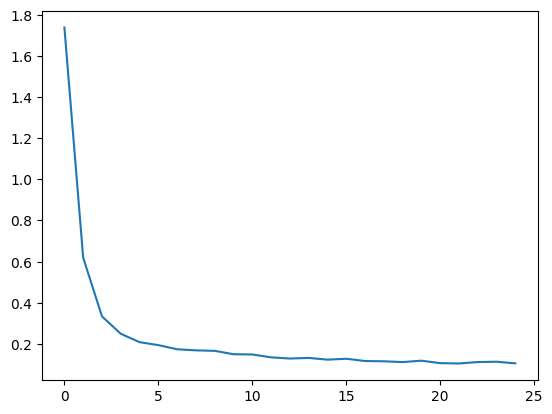

In [39]:
# Loss curve.
plt.plot(losses);

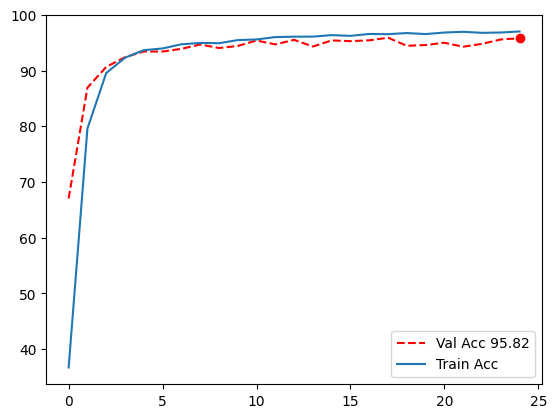

In [41]:
# Train vs validation accuracy. Compare the numbers with FNNs/MNIST.ipynb -
# the CNN gets there faster and higher, with fewer parameters.
plt.plot(val_acc, 'r--', label=f"Val Acc {val_acc[-1]:.2f}")
plt.plot(24,val_acc[-1], 'ro')
plt.plot(train_acc, label='Train Acc')
plt.legend();

## Testing

In [42]:
# The untouched test set, with the validation (non-augmenting) transform.
test_data_tensor = raw_data_test.data.detach().clone().to(dtype=torch.float, device=device)
test_label_tensor = raw_data_test.targets.detach().clone().to(dtype=torch.long, device=device)


test_dataset = MNIST_Dataset((test_data_tensor, test_label_tensor), transformations=val_transformation)

In [43]:
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], shuffle=False)

In [44]:
# Final evaluation, inside no_grad and after .eval().
with torch.no_grad():
  model.eval()
  a, b = next(iter(test_loader))
  test_predictions = model(a.to(device))

  test_acc = 100 * torch.mean( (torch.argmax(test_predictions, dim=1) == b.to(device)).float().detach().cpu())


In [45]:
# The headline number.
test_acc

tensor(96.1400)

In [46]:
# Per-digit precision, recall and F1. Look for which digits remain hardest -
# the confusions a CNN makes are usually fewer and different from an FNN's.
from sklearn.metrics import classification_report

preds = torch.argmax(test_predictions, dim=1).cpu().numpy()
true_labels = b.cpu().numpy()

print(classification_report(true_labels, preds, target_names=raw_data_test.classes))

              precision    recall  f1-score   support

    0 - zero       0.97      0.98      0.97       980
     1 - one       0.98      0.99      0.99      1135
     2 - two       0.94      0.96      0.95      1032
   3 - three       0.95      0.96      0.95      1010
    4 - four       0.98      0.96      0.97       982
    5 - five       0.96      0.91      0.94       892
     6 - six       0.96      0.97      0.97       958
   7 - seven       0.96      0.97      0.97      1028
   8 - eight       0.95      0.95      0.95       974
    9 - nine       0.95      0.96      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000

